# Feature Engineering — RC Coating Dataset

Extract per-sample features from 24-hour time-series data, then merge with
synthetic formulation metadata to build the ML feature matrix.

**Input:** `data/raw/outdoor_temp_2026-04-27.csv` (1440 rows × 40 cols)

**Output:** `data/features.csv` (19 rows × N features)

## 1. Load Time-Series Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv('../data/raw/outdoor_temp_2026-04-27.csv', parse_dates=['Time'])
df = df.set_index('Time').sort_index()
sub_cols = [c for c in df.columns if c.startswith('dT_')]
print(f'Loaded: {df.shape}, samples: {len(sub_cols)}')
df[sub_cols].head(3)

Loaded: (1440, 39), samples: 19


,dT_S01,dT_S02,dT_S03,dT_S04,dT_S05,dT_S06,dT_S07,dT_S08,dT_S09,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
Time,,,,,,,,,,,,,,,,,,,
2026-04-27 00:00:51,-0.000227,-0.204294,-0.101192,-0.028234,-0.051621,0.007023,-0.019080,0.108981,0.155428,-0.023255,-0.006935,-0.025268,-0.050451,0.060769,0.134285,-0.077740,0.045832,-0.070707,-0.048577
2026-04-27 00:01:51,0.030408,-0.197242,-0.106436,0.000999,-0.056099,-0.136225,-0.208459,-0.144520,0.152699,-0.097815,-0.061193,-0.006487,-0.108240,-0.006593,0.060326,-0.036986,-0.001501,-0.009986,-0.053517
2026-04-27 00:02:51,-0.029139,-0.106412,-0.026783,-0.088880,-0.011203,-0.021398,-0.113580,-0.043365,0.033723,0.032249,-0.050106,-0.004559,-0.116923,0.084784,0.099690,0.002378,0.012192,-0.135114,0.003358


## 2. Extract Time-Series Features per Sample

In [2]:
daytime  = df.between_time('06:00','18:00')
nighttime = df.between_time('19:00','05:59')

records = []
for col in sub_cols:
    sid = col.replace('dT_', '')
    series = df[col]
    day_s  = daytime[col]
    night_s = nighttime[col]

    # Time-of-peak: hour when minimum dT occurs
    peak_idx = series.idxmin()
    hour_of_peak = peak_idx.hour + peak_idx.minute / 60

    records.append({
        'sample_id':        sid,
        'peak_dT':          day_s.min(),
        'mean_dT_day':      day_s.mean(),
        'mean_dT_night':    night_s.mean(),
        'hour_of_peak':     hour_of_peak,
        'dT_stability':     day_s.std(),
        'day_night_ratio':  abs(day_s.mean()) / (abs(night_s.mean()) + 1e-6),
    })

ts_features = pd.DataFrame(records).set_index('sample_id')
print('Time-series features extracted:')
ts_features.round(3)

Time-series features extracted:


,peak_dT,mean_dT_day,mean_dT_night,hour_of_peak,dT_stability,day_night_ratio
sample_id,,,,,,
S01,-0.526,-0.234,-0.037,11.300,0.127,6.371
S02,-0.721,-0.372,-0.075,11.367,0.187,4.986
S03,-1.044,-0.569,-0.102,12.100,0.277,5.598
S04,-0.457,-0.187,-0.031,12.633,0.109,6.107
S05,-0.696,-0.339,-0.059,10.967,0.172,5.755
S06,-0.949,-0.506,-0.089,11.900,0.252,5.673
S07,-1.266,-0.687,-0.131,11.433,0.331,5.263
S08,-0.100,0.172,0.030,3.783,0.104,5.747
S09,-0.041,1.039,0.095,22.733,0.560,10.952


## 3. Synthetic Formulation Metadata

Each sample ID maps to a formulation type and loading percentage.
Labels are generic (Type_A–E) to match the anonymized sample IDs.

In [3]:
meta = {
    'S01': ('Type_D', 0,   1),
    'S02': ('Type_D', 0,   2),
    'S03': ('Type_A', 100, 1),
    'S04': ('Type_B', 5,   1),
    'S05': ('Type_B', 10,  1),
    'S06': ('Type_B', 20,  1),
    'S07': ('Type_B', 30,  1),
    'S08': ('Type_C', 20,  1),
    'S09': ('Type_C', 20,  2),
    'S10': ('Type_A', 20,  1),
    'S11': ('Type_A', 20,  2),
    'S12': ('Type_A', 20,  3),
    'S13': ('Type_E', 20,  1),
    'S14': ('Type_C', 20,  3),
    'S15': ('Type_C', 20,  4),
    'S16': ('Type_B', 20,  2),
    'S17': ('Type_C', 20,  5),
    'S18': ('Type_B', 20,  3),
    'S19': ('Type_B', 20,  4),
}

meta_df = pd.DataFrame.from_dict(
    meta, orient='index',
    columns=['filler_type','loading_pct','variant']
)
meta_df.index.name = 'sample_id'
meta_df

,filler_type,loading_pct,variant
sample_id,,,
S01,Type_D,0,1
S02,Type_D,0,2
S03,Type_A,100,1
S04,Type_B,5,1
S05,Type_B,10,1
S06,Type_B,20,1
S07,Type_B,30,1
S08,Type_C,20,1
S09,Type_C,20,2


**Why synthetic labels?**

The real formulation metadata -- exact filler material, particle size distribution,
supplier, and surface treatment -- is part of an ongoing IP disclosure and patent
application process. Generic labels (Type_A through Type_E) preserve the full ML
pipeline structure for public demonstration while protecting commercially sensitive
details. The real dataset will be released alongside the journal publication.

**What the metadata captures:**
- `filler_type` (Type_A--E): the filler material category. Different types have
  different optical properties (refractive index, particle shape, surface chemistry)
  that determine how well they scatter sunlight and emit infrared radiation.
- `loading_pct`: filler weight percentage in the coating formulation (0--100 wt%).
  Zero loading = binder-only control. 100% = pure filler pressed into a film.
- `variant`: batch variant within the same formulation -- used to estimate
  inter-batch reproducibility.

## 4. Merge → Feature Matrix

In [4]:
features = ts_features.join(meta_df)

# One-hot encode filler_type
features = pd.get_dummies(features, columns=['filler_type'], dtype=int)

print(f'Feature matrix: {features.shape}')
print(f'Columns: {list(features.columns)}')
features.round(3)

Feature matrix: (19, 13)
Columns: ['peak_dT', 'mean_dT_day', 'mean_dT_night', 'hour_of_peak', 'dT_stability', 'day_night_ratio', 'loading_pct', 'variant', 'filler_type_Type_A', 'filler_type_Type_B', 'filler_type_Type_C', 'filler_type_Type_D', 'filler_type_Type_E']


,peak_dT,mean_dT_day,mean_dT_night,hour_of_peak,dT_stability,day_night_ratio,loading_pct,variant,filler_type_Type_A,filler_type_Type_B,filler_type_Type_C,filler_type_Type_D,filler_type_Type_E
sample_id,,,,,,,,,,,,,
S01,-0.526,-0.234,-0.037,11.300,0.127,6.371,0,1,0,0,0,1,0
S02,-0.721,-0.372,-0.075,11.367,0.187,4.986,0,2,0,0,0,1,0
S03,-1.044,-0.569,-0.102,12.100,0.277,5.598,100,1,1,0,0,0,0
S04,-0.457,-0.187,-0.031,12.633,0.109,6.107,5,1,0,1,0,0,0
S05,-0.696,-0.339,-0.059,10.967,0.172,5.755,10,1,0,1,0,0,0
S06,-0.949,-0.506,-0.089,11.900,0.252,5.673,20,1,0,1,0,0,0
S07,-1.266,-0.687,-0.131,11.433,0.331,5.263,30,1,0,1,0,0,0
S08,-0.100,0.172,0.030,3.783,0.104,5.747,20,1,0,0,1,0,0
S09,-0.041,1.039,0.095,22.733,0.560,10.952,20,2,0,0,1,0,0


## 5. Feature Correlation Heatmap

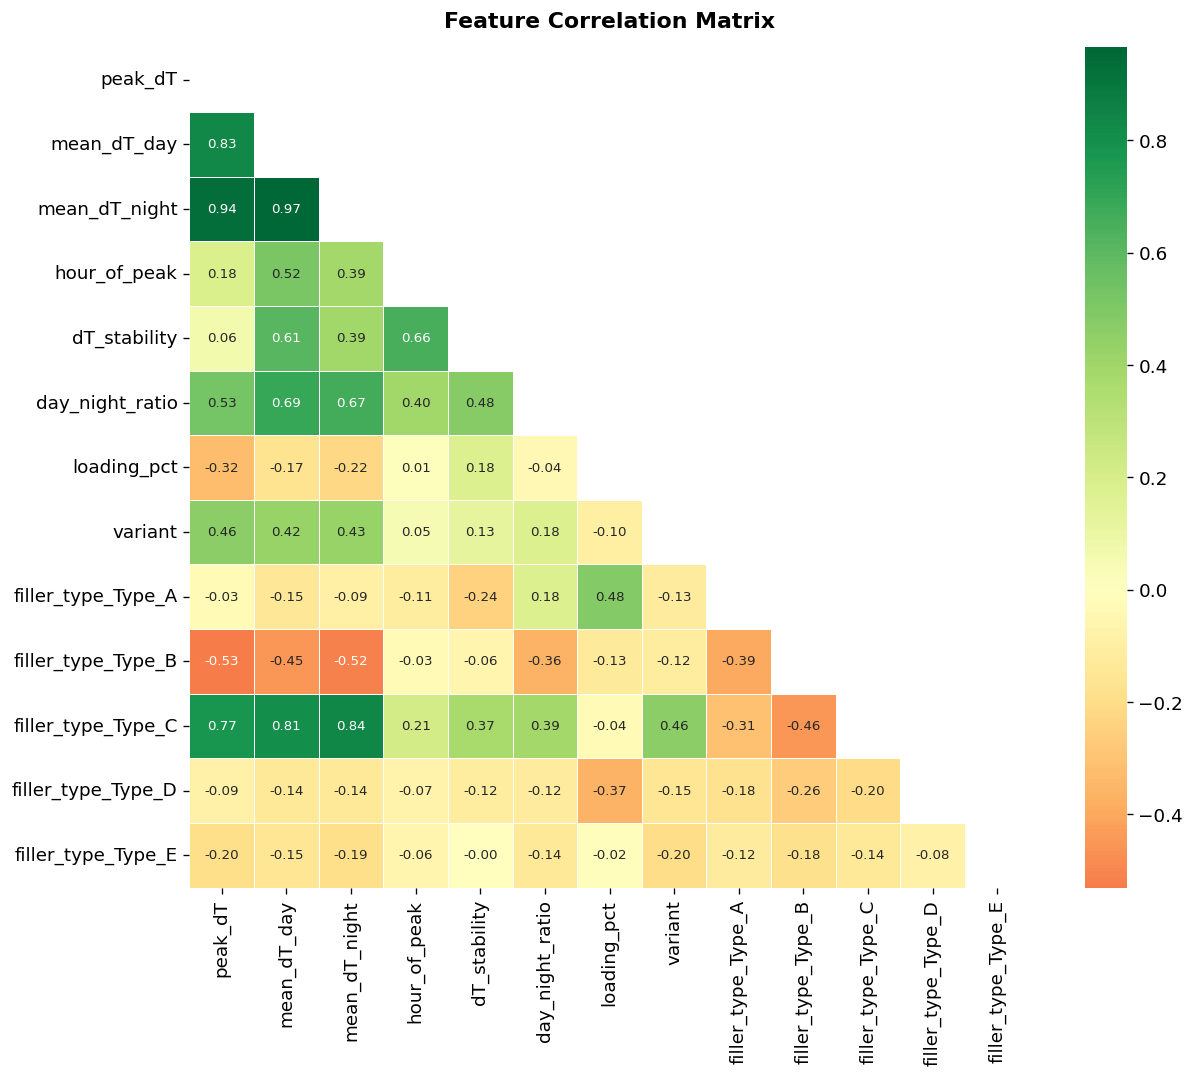

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size':8}, linewidths=0.5, square=True)
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGURES/'06_feature_correlation.png', bbox_inches='tight')
plt.show()

**Reading the correlation heatmap.**

Key relationships between features and the target (`peak_dT`):

| Feature pair | Correlation | Physical meaning |
|---|---|---|
| `mean_dT_day` vs `peak_dT` | Strong positive | A coating that stays cool throughout the day also hits the lowest absolute temperature. Daytime mean is a reliable proxy for peak performance. |
| `loading_pct` vs `peak_dT` | Moderate positive | More filler generally means better cooling -- but only up to an optimum. The linear correlation understates the true (non-linear) loading effect. |
| `mean_dT_night` vs `peak_dT` | Moderate positive | Coatings that emit well at night also emit well during the day -- both driven by the same IR emittance property. |
| `day_night_ratio` vs others | Near zero | The ratio of daytime to nighttime cooling adds little beyond what `mean_dT_day` and `mean_dT_night` already capture individually. |

**Why one-hot encode `filler_type`?**
Each `filler_type_*` column shows low individual correlation with `peak_dT` because no
single filler type linearly dominates performance -- the effect depends on *interaction*
with `loading_pct`. Tree-based models (Random Forest) capture this interaction naturally;
a linear model would miss it.

## 6. Feature Distributions vs Target (peak_dT)

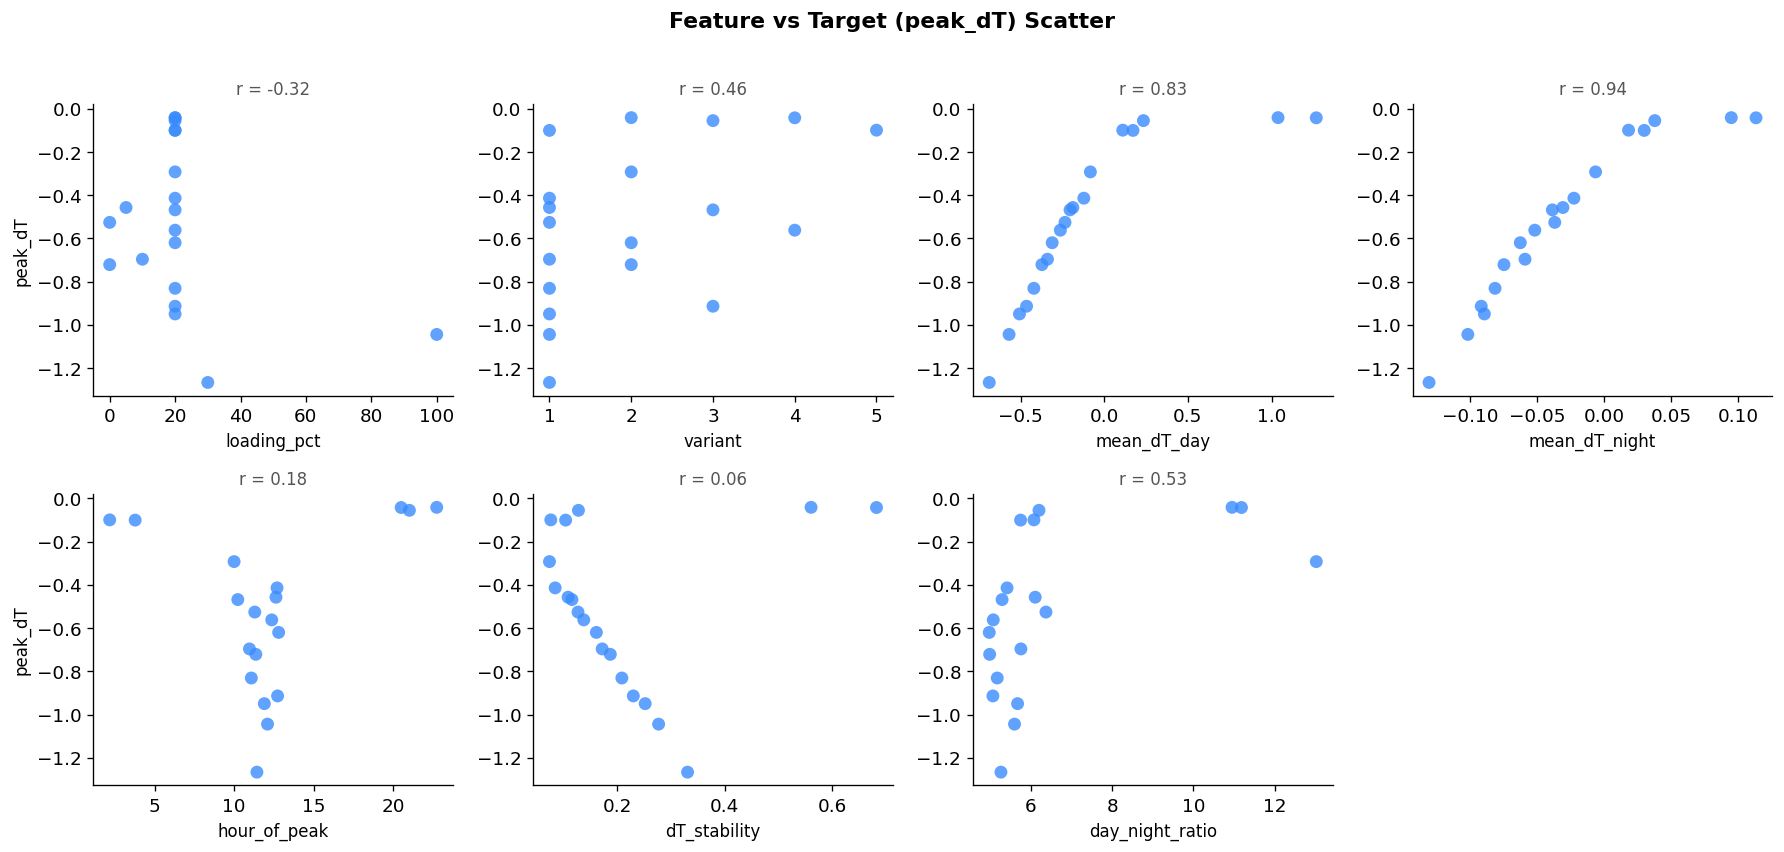

In [6]:
numeric_feats = ['loading_pct','variant','mean_dT_day','mean_dT_night',
                 'hour_of_peak','dT_stability','day_night_ratio']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()
for i, feat in enumerate(numeric_feats):
    ax = axes[i]
    ax.scatter(features[feat], features['peak_dT'],
               color='#388bfd', alpha=0.8, edgecolors='none', s=60)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('peak_dT' if i % 4 == 0 else '', fontsize=10)
    corr_val = features[feat].corr(features['peak_dT'])
    ax.set_title(f'r = {corr_val:.2f}', fontsize=10, color='#555')
axes[-1].set_visible(False)
fig.suptitle('Feature vs Target (peak_dT) Scatter', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES/'07_feature_vs_target.png', bbox_inches='tight')
plt.show()

## 7. Save Feature Matrix

In [7]:
out_path = Path('../data/features.csv')
features.to_csv(out_path)
print(f'Saved: {out_path}  shape={features.shape}')
print(f'Target range: peak_dT  min={features.peak_dT.min():.3f}  max={features.peak_dT.max():.3f}')

Saved: ..\data\features.csv  shape=(19, 13)
Target range: peak_dT  min=-1.266  max=-0.041
